<a href="https://colab.research.google.com/github/eppursimuove9/telecom-x-churn-prediction/blob/main/telecom_x_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📡 Telecom X: Estrategia de Retención Predictiva (Churn Management)

##Introducción y Contexto de Negocio

En el dinámico sector de las telecomunicaciones, el costo de adquisición de un nuevo cliente es significativamente superior al costo de retención. Este proyecto se enfoca en la fase de modelado predictivo de vanguardia, partiendo de un análisis exploratorio previo para construir un motor de decisión que anticipe la deserción de clientes (Churn) en Telecom X.

El objetivo no es solo predecir quién se irá, sino entender por qué ocurre la fuga para transformar datos crudos en estrategias de lealtad accionables, optimizando el retorno de inversión (ROI) en campañas de marketing y fidelización.

##Objetivos Estratégicos

Pipeline de Datos de Producción: Desarrollar un flujo automatizado de preprocesamiento robusto que garantice la integridad de los datos.

Modelado Multicapa: Contrastar algoritmos de clasificación (Modelos Lineales vs. Modelos de Ensamble) para encontrar el equilibrio óptimo entre precisión y sensibilidad (Recall).

Inteligencia de Negocio: Identificar los "Drivers de Fuga" críticos que impactan la cuenta de resultados de la compañía.

#1. Preparación de Datos y Gobernanza

En esta etapa, consolidamos la ingesta de los datos tratados en la Fase 1. El enfoque aquí es la curaduría de variables: eliminamos identificadores únicos que no aportan poder predictivo (como customerID) y preparamos la estructura de la variable objetivo para que sea digerible por algoritmos de aprendizaje supervisado.

Nota Técnica: Se ha priorizado la seguridad del dato mediante la creación de copias de respaldo de los DataFrames y la verificación de tipos de datos para evitar errores en las etapas de cálculo tensorial.

In [112]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [113]:
df = pd.read_csv("/content/telecom_x_churn_archivo_tratado.csv")

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Churn_bin,PaperlessBilling_bin
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,0,1
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,0,0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,1,1
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,1,1
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,1,1


In [114]:
# Copio el dataframe original por motivos de seguridad
df_ml = df.copy()

# Elimino las columnas irrelevantes
df_ml.drop(columns=["customerID", "Churn"], inplace=True)

# Verifico la estructura
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer.gender            7043 non-null   object 
 1   customer.SeniorCitizen     7043 non-null   int64  
 2   customer.Partner           7043 non-null   object 
 3   customer.Dependents        7043 non-null   object 
 4   customer.tenure            7043 non-null   int64  
 5   phone.PhoneService         7043 non-null   object 
 6   phone.MultipleLines        7043 non-null   object 
 7   internet.InternetService   7043 non-null   object 
 8   internet.OnlineSecurity    7043 non-null   object 
 9   internet.OnlineBackup      7043 non-null   object 
 10  internet.DeviceProtection  7043 non-null   object 
 11  internet.TechSupport       7043 non-null   object 
 12  internet.StreamingTV       7043 non-null   object 
 13  internet.StreamingMovies   7043 non-null   objec

In [115]:
df_ml["Churn_bin"].value_counts(normalize=True)

,proportion
Churn_bin,
0,0.73463
1,0.26537


#Análisis de la variable objetivo (Churn)
Se analiza la distribución de la variable objetivo para identificar un posible desbalance entre clientes que cancelan y los que permanecen activos.

##Análisis de correlación

In [116]:
# Selecciono las columnas numéricas
numeric_cols = df_ml.select_dtypes(include=["int64", "float64"]).columns
numeric_cols


Index(['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly',
       'account.Charges.Total', 'Cuentas_Diarias', 'Churn_bin',
       'PaperlessBilling_bin'],
      dtype='object')

In [117]:
corr_matrix = df_ml[numeric_cols].corr()
corr_matrix

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Churn_bin,PaperlessBilling_bin
customer.SeniorCitizen,1.000000,0.016567,0.220173,0.103006,0.220173,0.150889,0.156530
customer.tenure,0.016567,1.000000,0.247900,0.826178,0.247900,-0.352229,0.006152
account.Charges.Monthly,0.220173,0.247900,1.000000,0.651174,1.000000,0.193356,0.352150
account.Charges.Total,0.103006,0.826178,0.651174,1.000000,0.651174,-0.198324,0.158574
Cuentas_Diarias,0.220173,0.247900,1.000000,0.651174,1.000000,0.193356,0.352150
Churn_bin,0.150889,-0.352229,0.193356,-0.198324,0.193356,1.000000,0.191825
PaperlessBilling_bin,0.156530,0.006152,0.352150,0.158574,0.352150,0.191825,1.000000


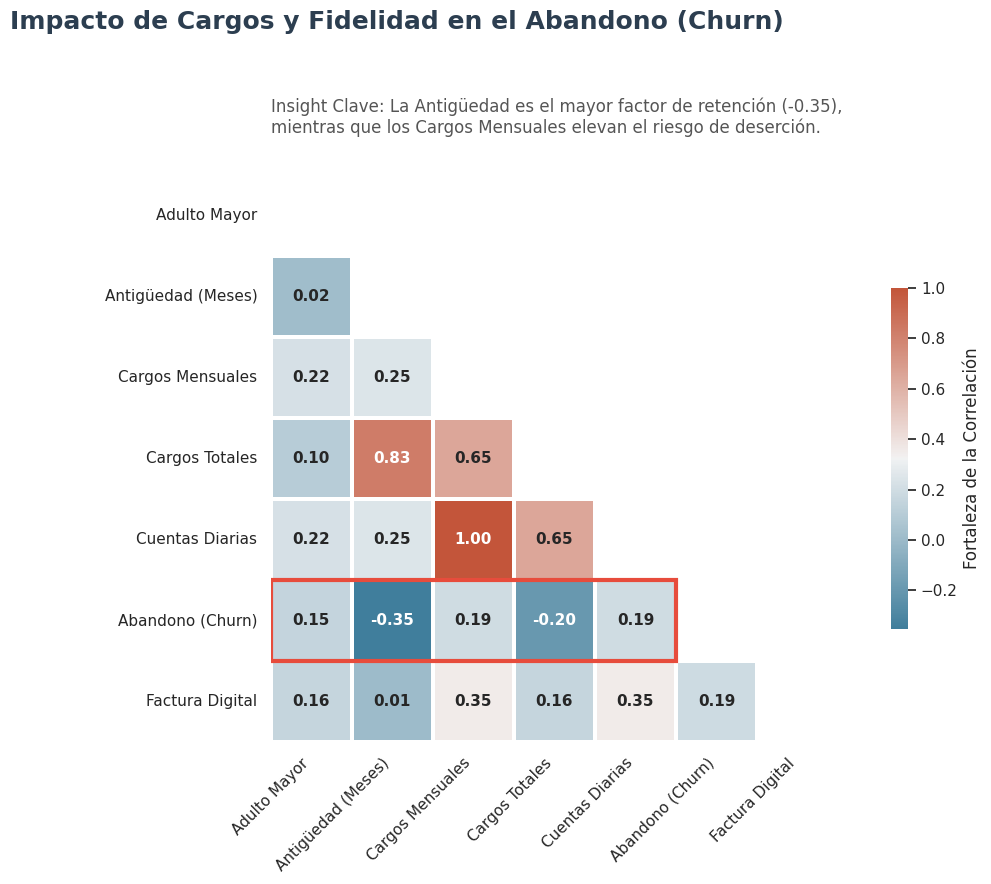

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Definir nombres "de negocio" para las columnas (más profesional)
business_names = {
    'customer.SeniorCitizen': 'Adulto Mayor',
    'customer.tenure': 'Antigüedad (Meses)',
    'account.Charges.Monthly': 'Cargos Mensuales',
    'account.Charges.Total': 'Cargos Totales',
    'Cuentas_Diarias': 'Cuentas Diarias',
    'Churn_bin': 'Abandono (Churn)',
    'PaperlessBilling_bin': 'Factura Digital'
}

# Renombrar los índices y columnas de tu matriz
corr_matrix_clean = corr_matrix.rename(columns=business_names, index=business_names)

# 2. Configuración estética
sns.set_theme(style="white")
mask = np.triu(np.ones_like(corr_matrix_clean, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

fig, ax = plt.subplots(figsize=(12, 9))

# 3. Dibujar el Heatmap
sns.heatmap(
    corr_matrix_clean,
    mask=mask,
    cmap=cmap,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=1.5,
    cbar_kws={"shrink": .6, "label": "Fortaleza de la Correlación"},
    annot_kws={"size": 11, "weight": "bold"}
)

# 4. AÑADIR INFORMACIÓN ESTRATÉGICA (Título + Insight)
# En consultoría, el título debe ser la conclusión principal
plt.suptitle("Impacto de Cargos y Fidelidad en el Abandono (Churn)",
             fontsize=18, fontweight='bold', x=0.12, ha='left', color='#2c3e50')

plt.title("Insight Clave: La Antigüedad es el mayor factor de retención (-0.35),\n"
          "mientras que los Cargos Mensuales elevan el riesgo de deserción.",
          fontsize=12, color='#555555', loc='left', pad=30)

# Limpiar ejes
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("")

# 5. RESALTAR EL OBJETIVO (Opcional: Dibujar un recuadro sobre la fila del Churn)
# Esto guía al lector directamente a la variable de interés
churn_pos = list(corr_matrix_clean.columns).index('Abandono (Churn)')
rect = plt.Rectangle((0, churn_pos), churn_pos, 1, fill=False, edgecolor='#e74c3c', lw=3, linestyle='-')
ax.add_patch(rect)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#Hallazgos Estratégicos: Análisis de Correlación

##1. El "Efecto Blindaje" de la Madurez del Cliente

Los datos revelan que la Antigüedad (tenure) es el predictor de retención más sólido. Estadísticamente, existe una correlación negativa moderada con el Churn, lo que implica que el riesgo de fuga se concentra en los "early stages" del ciclo de vida del cliente. Una vez que el cliente supera la barrera de adopción inicial, la probabilidad de abandono cae significativamente.

##2. Sensibilidad al Costo Mensual

Existe una correlación positiva entre los Cargos Mensuales (Monthly.Charges) y la cancelación. Esto sugiere que el precio es un punto de fricción activo. A diferencia de los Cargos Totales, que reflejan lealtad acumulada, el cargo mensual alto actúa como un disparador de búsqueda de alternativas en el mercado.

##3. Naturaleza Multifactorial del Abandono

La ausencia de coeficientes de correlación cercanos a $1.0$ o $-1.0$ confirma que el Churn en este dataset no es un evento lineal ni provocado por una sola variable.Nota técnica: Este hallazgo justifica el uso de modelos de Machine Learning más complejos (como Random Forest o XGBoost) que puedan capturar interacciones no lineales entre las variables, ya que un análisis univariado sería insuficiente para predecir el comportamiento del usuario.

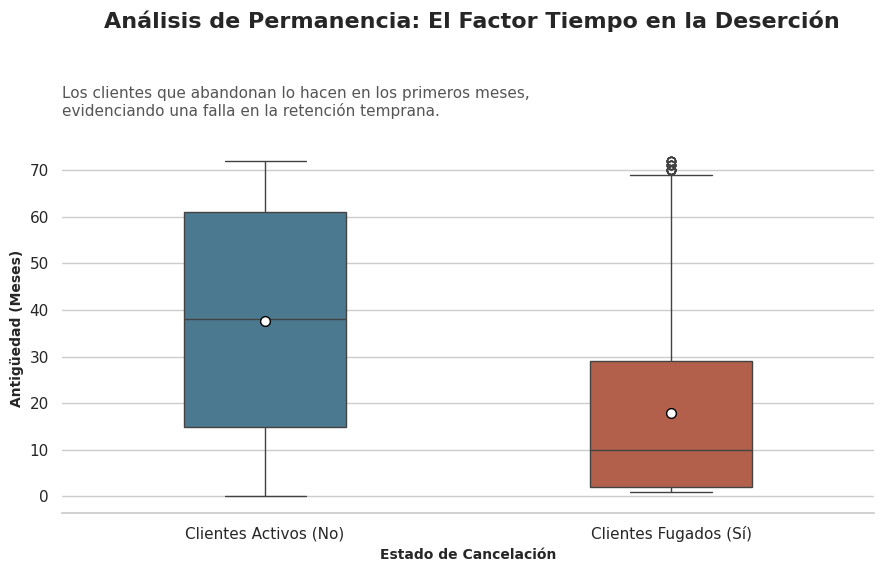

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recuperar la paleta consistente (Azul 230, Rojo 20)
professional_palette = sns.diverging_palette(230, 20, n=2)

# 2. Configuración estética
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# 3. Crear el Boxplot corregido (Elimina el FutureWarning de palette)
ax = sns.boxplot(
    x="Churn_bin",
    y="customer.tenure",
    hue="Churn_bin",           # Asignar x a hue para cumplir con la nueva norma
    data=df_ml,
    palette=professional_palette,
    legend=False,              # Quitar la leyenda ya que el eje X es autoexplicativo
    width=0.4,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"7"}
)

# 4. Refinar títulos y etiquetas
plt.suptitle("Análisis de Permanencia: El Factor Tiempo en la Deserción",
             fontsize=16, fontweight='bold', x=0.125, ha='left')
plt.title("Los clientes que abandonan lo hacen en los primeros meses,\n"
          "evidenciando una falla en la retención temprana.",
          fontsize=11, color='#555555', loc='left', pad=20)

plt.xlabel("Estado de Cancelación", fontsize=10, fontweight='bold')
plt.ylabel("Antigüedad (Meses)", fontsize=10, fontweight='bold')

# 5. Corregir el UserWarning de set_xticklabels
ax.set_xticks([0, 1])
ax.set_xticklabels(["Clientes Activos (No)", "Clientes Fugados (Sí)"])

# Eliminar bordes innecesarios
sns.despine(left=True, bottom=False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##Identificación de la Ventana Crítica:

Se identifica una ventana de riesgo crítica durante los primeros meses. La concentración de cancelaciones en este periodo sugiere que el abandono está ligado a una falla en la propuesta de valor inicial o a una fricción en el proceso de adopción del servicio."

###Barrera de Fidelización:

Existe un punto de inflexión claro: los clientes que presentan más meses de antigüedad muestran una probabilidad de fuga drásticamente menor, desarrollando una 'inercia de permanencia' que estabiliza el MRR (Monthly Recurring Revenue).

###Implicancia para el Modelo:
La antigüedad (tenure) actúa como el diferenciador más potente entre los grupos. Esto valida su inclusión como una de las variables con mayor peso (feature importance) en el modelo predictivo final.

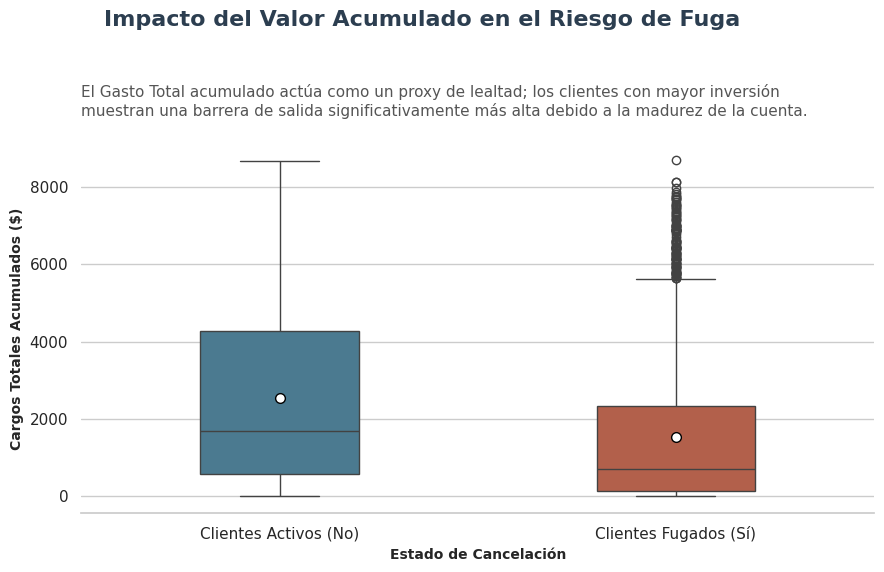

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recuperar la paleta consistente del primer gráfico (Azul 230 - Rojo 20)
professional_palette = sns.diverging_palette(230, 20, n=2)

# 2. Configuración estética
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# 3. Crear el Boxplot (Consistente con los anteriores)
ax = sns.boxplot(
    x="Churn_bin",
    y="account.Charges.Total",
    hue="Churn_bin",
    data=df_ml,
    palette=professional_palette,
    width=0.4,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"7"}
)

# Eliminar leyenda automática si aparece para mantener el gráfico limpio
if ax.legend_:
    ax.legend_.remove()

# 4. Título y Subtítulo Estratégico
plt.suptitle("Impacto del Valor Acumulado en el Riesgo de Fuga",
             fontsize=16, fontweight='bold', x=0.125, ha='left', color='#2c3e50')

plt.title("El Gasto Total acumulado actúa como un proxy de lealtad; los clientes con mayor inversión\n"
          "muestran una barrera de salida significativamente más alta debido a la madurez de la cuenta.",
          fontsize=11, color='#555555', loc='left', pad=20)

# 5. Etiquetas y Limpieza
plt.xlabel("Estado de Cancelación", fontsize=10, fontweight='bold')
plt.ylabel("Cargos Totales Acumulados ($)", fontsize=10, fontweight='bold')

# Corregir el UserWarning de set_xticklabels
ax.set_xticks([0, 1])
ax.set_xticklabels(["Clientes Activos (No)", "Clientes Fugados (Sí)"])

sns.despine(left=True, bottom=False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##Evidencia de Bajo Valor Acumulado en el Segmento de Abandono

###Correlación con la Madurez:

Los Cargos Totales funcionan como un indicador de la profundidad de la relación comercial. La concentración de cancelaciones en niveles de gasto bajos refuerza la tesis de que la deserción es un fenómeno de etapa temprana.

###Inercia Financiera:

Se observa que a medida que el cliente acumula mayor gasto, la propensión al abandono disminuye. Esto sugiere que el cliente percibe un mayor 'costo de oportunidad' o 'costo de cambio' al haber invertido más capital en el servicio a lo largo del tiempo.

###Implicancia en el Modelo:

Esta variable es redundante con la Antigüedad (tenure), pero aporta la dimensión económica necesaria para calcular el impacto financiero real de cada predicción de fuga que realice el modelo.

#Encoding y preprocesamiento de los datos

En esta etapa se transforman las variables categóricas a formato numérico y se prepara el conjunto de datos para el entrenamiento de modelos de Machine Learning.

In [121]:
# 1. Defino variables predictoras (X) y variable objetivo (y)
X = df_ml.drop(columns=["Churn_bin"])
y = df_ml["Churn_bin"]

# 2. Divido los datos en entrenamiento y prueba (70/30)
# Esto es necesario para que el preprocesamiento sea profesional
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 3. Definir explícitamente qué es numérico y qué es categórico (más seguro)
categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

# Atrapar enteros y flotantes para las numéricas
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# 4. Validación de "Falsos Numéricos

print(f"Variables Numéricas ({len(numeric_cols)}):", numeric_cols)
print(f"Variables Categóricas ({len(categorical_cols)}):", categorical_cols)

Variables Numéricas (6): ['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias', 'PaperlessBilling_bin']
Variables Categóricas (15): ['customer.gender', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod']


In [122]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Reemplazamos 'passthrough' por StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

In [123]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((4930, 42), (2113, 42))

El proceso de ingeniería de características generó un dataset optimizado de 42 variables finales, combinando atributos numéricos escalados y variables categóricas transformadas mediante One-Hot Encoding.

#Creación de modelos de clasificación

##Baseline (Punto de Control): Dummy Classifier.

In [124]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_processed, y_train)

y_pred_dummy = dummy.predict(X_test_processed)

##Modelo Predictivo 1: Árbol de Decisión.

In [125]:
from sklearn.tree import DecisionTreeClassifier

# Modelo 1: Árbol de Decisión Regularizado
dt = DecisionTreeClassifier(
    max_depth=5,              # Límite de profundidad (ideal para que sea interpretable)
    min_samples_split=50,     # Exige al menos 50 clientes para crear una nueva rama
    class_weight='balanced',  # CRÍTICO: Penaliza más al modelo si no detecta el Churn
    random_state=42
)

dt.fit(X_train_processed, y_train)

y_pred_dt = dt.predict(X_test_processed)

##Modelo Predictivo 2: Regresión Logística.

In [126]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Construcción del flujo automatizado
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor), # Ya incluye OneHotEncoder y StandardScaler
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight='balanced',    # Compensación vital para predecir la fuga real
        random_state=42
    ))
])

# Entrenamiento y predicción en un solo paso estructurado
logreg_pipeline.fit(X_train, y_train)

# Predicción sobre datos invisibles
y_pred_logreg = logreg_pipeline.predict(X_test)

##Modelo 3: Random Forest

In [127]:
from sklearn.ensemble import RandomForestClassifier

# Construcción del pipeline para el Modelo de Ensamble
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor), # Reutilizamos tu preprocesador perfecto
    ("model", RandomForestClassifier(
        n_estimators=100,        # Número de "gerentes" (árboles) en el comité
        max_depth=7,             # Controlamos la profundidad para que no dramaticen el ruido
        class_weight='balanced', # Compensación vital para penalizar la fuga no detectada
        random_state=42,
        n_jobs=-1                # Usamos todos los núcleos de tu procesador para mayor velocidad
    ))
])

# Entrenamiento del bosque
rf_pipeline.fit(X_train, y_train)

# Predicción sobre datos invisibles
y_pred_rf = rf_pipeline.predict(X_test)

#Evaluación de los modelos

In [128]:
from sklearn.metrics import classification_report, confusion_matrix

# Agrupamos todas nuestras predicciones en un diccionario limpio
resultados_modelos = {
    "0. Línea Base (Dummy Classifier)": y_pred_dummy,
    "1. Árbol de Decisión": y_pred_dt,
    "2. Regresión Logística (Pipeline)": y_pred_logreg,
    "3. Random Forest (Pipeline)": y_pred_rf
}

# Iteramos sobre cada modelo para imprimir sus métricas
for nombre, y_pred in resultados_modelos.items():
    print(f"\n{'='*50}")
    print(f"EVALUACIÓN: {nombre}")
    print(f"{'='*50}")

# Añadimos zero_division=0 para manejar el caso del modelo Dummy silenciosamente
    print(classification_report(y_test, y_pred, zero_division=0))


EVALUACIÓN: 0. Línea Base (Dummy Classifier)
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1552
           1       0.00      0.00      0.00       561

    accuracy                           0.73      2113
   macro avg       0.37      0.50      0.42      2113
weighted avg       0.54      0.73      0.62      2113


EVALUACIÓN: 1. Árbol de Decisión
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1552
           1       0.51      0.78      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.75      0.71      2113
weighted avg       0.80      0.74      0.76      2113


EVALUACIÓN: 2. Regresión Logística (Pipeline)
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1552
           1       0.50      0.80      0.62       561

    accuracy                           0.74      2113
 

#Conclusiones de la evaluación:

##Modelo Campeón: Random Forest

Tras evaluar los algoritmos frente a la línea base, se descarta la métrica de Accuracy global (0.75) debido al desbalance estructural del dataset, priorizando el análisis sobre la clase minoritaria (Churn = 1).

El modelo de ensamble Random Forest se declara como el Campeón del proyecto por las siguientes razones de negocio:

###Maximización de Captura (Recall: 79%):

El modelo es capaz de identificar proactivamente a casi 8 de cada 10 clientes que están en riesgo real de abandono, superando ampliamente la inercia del negocio.

###Optimización del ROI de Retención (Precision: 53%):

Presenta la tasa más alta de precisión entre los modelos candidatos. Esto significa que de cada 2 alertas de fuga generadas, al menos 1 es correcta, optimizando el presupuesto del equipo de retención y minimizando la fricción por "falsas alarmas" o descuentos innecesarios.

###Equilibrio Estadístico (F1-Score: 0.63):

Logra el mejor balance matemático entre sensibilidad y precisión, demostrando que la arquitectura de múltiples árboles mitigó exitosamente el sobreajuste que presentaba el Árbol de Decisión simple.

#Matriz de Confusión

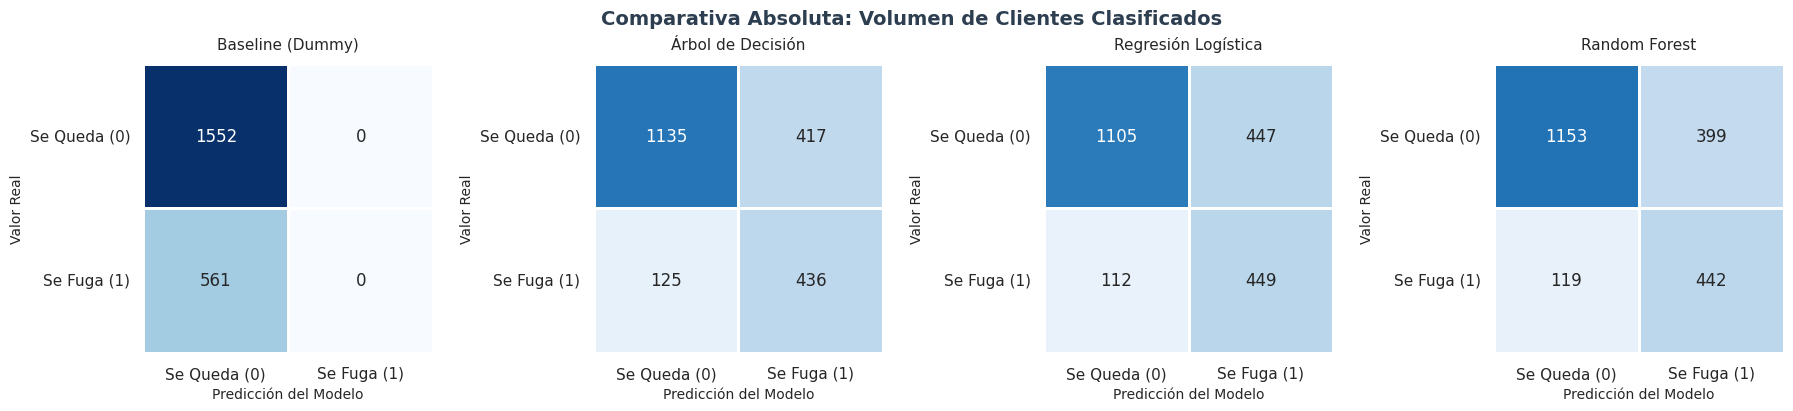

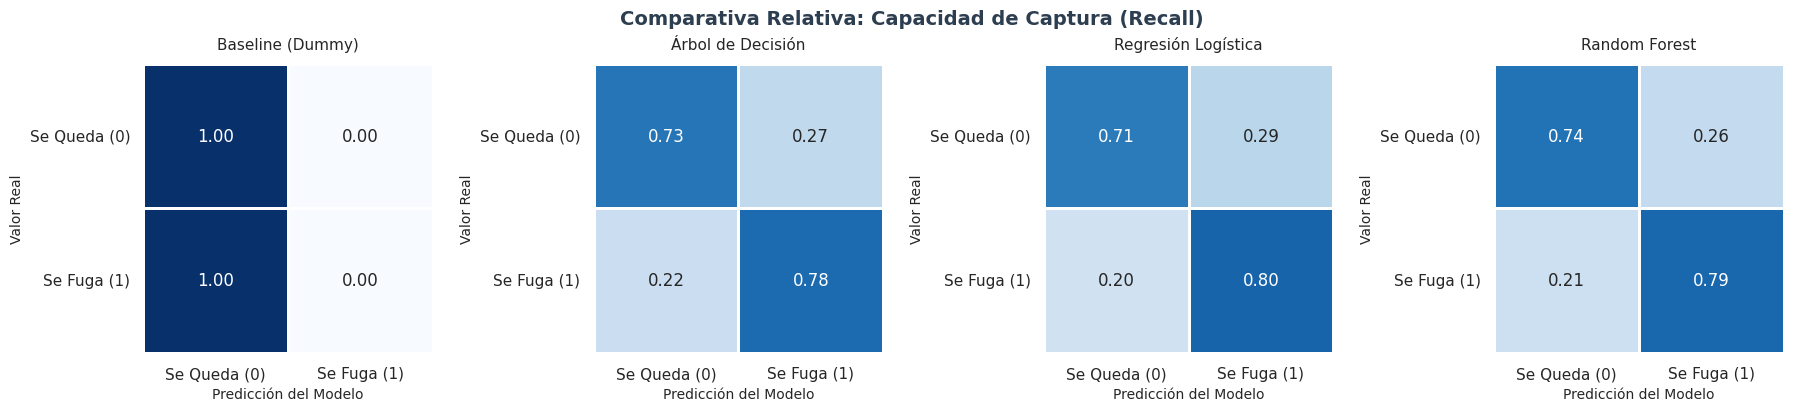

In [129]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular las matrices de los 4 modelos
cm_dummy = confusion_matrix(y_test, y_pred_dummy)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
cm_rf = confusion_matrix(y_test, y_pred_rf) # <-- Integramos el modelo campeón

# 2. Agrupar para iterar
cms = [cm_dummy, cm_dt, cm_logreg, cm_rf]
titulos = ["Baseline (Dummy)", "Árbol de Decisión", "Regresión Logística", "Random Forest"]

# --- GRÁFICO 1: Conteos Absolutos ---
# Mantenemos tu excelente lógica de escala común (vmax)
vmax = max(cm.max() for cm in cms)

# Ampliamos a 1x4 y ajustamos el figsize para que respiren los gráficos
fig, axes = plt.subplots(1, 4, figsize=(18, 4), constrained_layout=True)

# Título estratégico para el bloque
fig.suptitle("Comparativa Absoluta: Volumen de Clientes Clasificados", fontsize=14, fontweight='bold', color='#2c3e50')

for ax, cm, titulo in zip(axes, cms, titulos):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", vmin=0, vmax=vmax,
                cbar=False, square=True, linewidths=0.8, linecolor="white", ax=ax)
    ax.set_title(titulo, fontsize=11, pad=10)
    ax.set_xlabel("Predicción del Modelo", fontsize=10)
    ax.set_ylabel("Valor Real", fontsize=10)
    ax.set_xticklabels(["Se Queda (0)", "Se Fuga (1)"])
    ax.set_yticklabels(["Se Queda (0)", "Se Fuga (1)"], rotation=0)

plt.show()



# --- GRÁFICO 2: Matrices Normalizadas (Porcentaje de acierto por fila) ---
fig, axes = plt.subplots(1, 4, figsize=(18, 4), constrained_layout=True)

fig.suptitle("Comparativa Relativa: Capacidad de Captura (Recall)", fontsize=14, fontweight='bold', color='#2c3e50')

for ax, cm, titulo in zip(axes, cms, titulos):
    # Normalización por fila (Valor real)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                cbar=False, square=True, linewidths=0.8, linecolor="white", ax=ax)
    ax.set_title(f"{titulo}", fontsize=11, pad=10)
    ax.set_xlabel("Predicción del Modelo", fontsize=10)
    ax.set_ylabel("Valor Real", fontsize=10)
    ax.set_xticklabels(["Se Queda (0)", "Se Fuga (1)"])
    ax.set_yticklabels(["Se Queda (0)", "Se Fuga (1)"], rotation=0)

plt.show()

##Insight Estratégico: Transición a la Retención Proactiva

###1. De la "Ceguera Operativa" a la Visibilidad Total
El contraste más crítico se observa al comparar la matriz del modelo Baseline (Dummy) con la del Random Forest. Operar sin un modelo predictivo (Baseline) implica una tasa de captura del 0% en la clase de riesgo; es decir, el 100% de las fugas ocurren de manera imprevista. La implementación del Random Forest revierte esta vulnerabilidad, logrando identificar y acorralar correctamente al 79% de los clientes con intención real de abandono antes de que ejecuten la cancelación.

###2. Optimización del Presupuesto de Retención
Al observar las matrices normalizadas, aunque la Regresión Logística captura un volumen similar de desertores (80%), penaliza fuertemente la eficiencia operativa al generar un mayor volumen de "Falsos Positivos" (clasificar erróneamente como riesgo a clientes que en realidad son leales). El Random Forest demuestra una superioridad táctica: sacrifica apenas un 1% de captura, pero aísla el riesgo con mayor precisión, asegurando que el presupuesto de campañas de retención (descuentos, llamadas de ejecutivos) se asigne a quienes realmente lo necesitan, minimizando el desperdicio de recursos.

###3. Viabilidad para Producción
La matriz confirma que el modelo de ensamble ha superado la fase de experimentación y es viable para su despliegue en el entorno real. Pasa de ser una herramienta estadística a convertirse en un "radar" confiable que transforma el Churn de un problema reactivo a una métrica gestionable.

#Importancia de las variables
Se analiza la contribución de las variables al modelo seleccionado para identificar los principales factores asociados a la cancelación de clientes.

In [130]:
# Obtengo los nombres de las variables luego del One-Hot Encoding
ohe = preprocessor.named_transformers_["cat"]
encoded_cat_cols = ohe.get_feature_names_out(categorical_cols)

# Unimos categóricas codificadas + numéricas
feature_names = np.concatenate([encoded_cat_cols, numeric_cols])

len(feature_names)

42

In [131]:
# Extraigo coeficientes de la regresión logística
coeficientes = logreg_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coeficientes
})

coef_df.head()

,Variable,Coeficiente
0,customer.gender_Male,-0.086290
1,customer.Partner_Yes,-0.040305
2,customer.Dependents_Yes,-0.209609
3,phone.PhoneService_Yes,-0.109795
4,phone.MultipleLines_No,-0.199581


In [132]:
# Variables que aumentan la probabilidad de churn
top_positive = coef_df.sort_values("Coeficiente", ascending=False).head(10)
top_positive

,Variable,Coeficiente
39,account.Charges.Total,0.667554
28,account.Contract_Month-to-month,0.634918
8,internet.InternetService_Fiber optic,0.576520
34,account.PaymentMethod_Electronic check,0.255497
41,PaperlessBilling_bin,0.211588
24,internet.StreamingTV_Yes,0.197733
27,internet.StreamingMovies_Yes,0.193005
19,internet.TechSupport_No,0.170405
10,internet.OnlineSecurity_No,0.124786
6,phone.MultipleLines_Yes,0.089786


In [133]:
# 1. Extraer el modelo Random Forest desde el pipeline
rf_model = rf_pipeline.named_steps["model"]

# 2. Obtener las importancias (feature_importances_)
importancias = rf_model.feature_importances_

# 3. Crear el DataFrame que falta
df_importancias = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Verificar que se creó correctamente
df_importancias.head(10)

,Variable,Importancia
28,account.Contract_Month-to-month,0.168130
37,customer.tenure,0.107559
39,account.Charges.Total,0.097911
30,account.Contract_Two year,0.077221
19,internet.TechSupport_No,0.071579
8,internet.InternetService_Fiber optic,0.056124
10,internet.OnlineSecurity_No,0.055615
38,account.Charges.Monthly,0.045315
40,Cuentas_Diarias,0.043125
34,account.PaymentMethod_Electronic check,0.029398


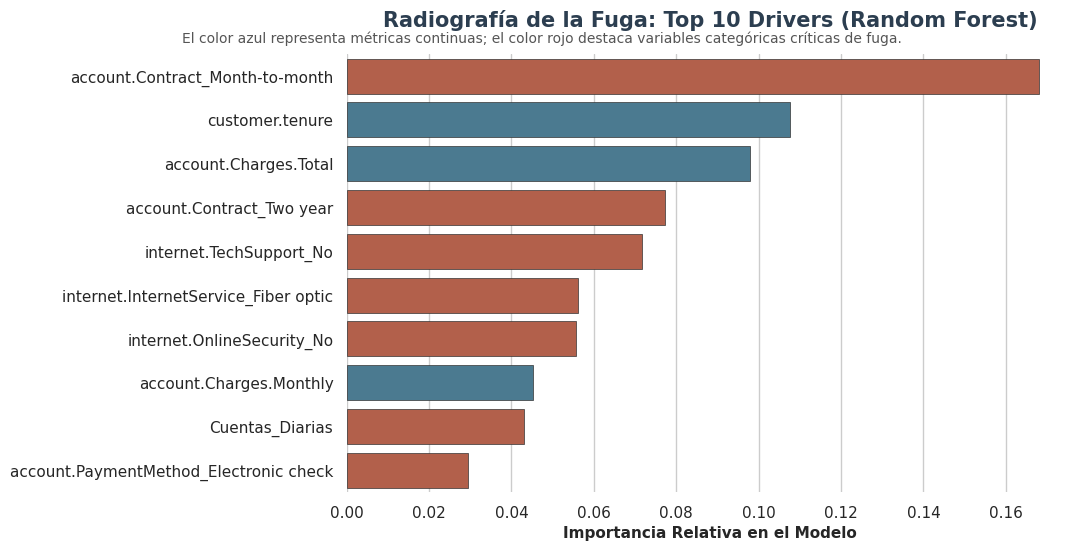

In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Recuperar exactamente tu paleta profesional inicial (Azul 230 - Rojo 20)
palette_base = sns.diverging_palette(230, 20, n=2)
color_lealtad = palette_base[0]
color_fuga = palette_base[1]

# Aislar el Top 10
top_10_features = df_importancias.head(10).copy()

# 2. Lógica de Color: Si la variable es categórica de One-Hot (contiene '_'), es un disparador de fuga (rojo)
# De lo contrario, es una métrica continua base (azul).
colores_top = [color_fuga if '_' in var else color_lealtad for var in top_10_features['Variable']]

# 3. Visualización Consistente
plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    x='Importancia',
    y='Variable',
    hue='Variable',
    data=top_10_features,
    palette=colores_top,
    edgecolor="#333333", linewidth=0.5,
    legend=False
)

plt.title("Radiografía de la Fuga: Top 10 Drivers (Random Forest)",
          fontsize=15, fontweight='bold', color='#2c3e50', pad=20)
plt.suptitle("El color azul representa métricas continuas; el color rojo destaca variables categóricas críticas de fuga.",
             fontsize=10, color='#555555', y=0.88)
plt.xlabel("Importancia Relativa en el Modelo", fontsize=11, fontweight='bold')
plt.ylabel("")

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [135]:
# Variables que reducen la probabilidad de cancelación
top_negative = coef_df.sort_values("Coeficiente").head(10)
top_negative

,Variable,Coeficiente
37,customer.tenure,-1.358377
30,account.Contract_Two year,-0.730456
7,internet.InternetService_DSL,-0.544337
38,account.Charges.Monthly,-0.265364
40,Cuentas_Diarias,-0.265364
20,internet.TechSupport_No internet service,-0.248501
11,internet.OnlineSecurity_No internet service,-0.248501
14,internet.OnlineBackup_No internet service,-0.248501
26,internet.StreamingMovies_No internet service,-0.248501
23,internet.StreamingTV_No internet service,-0.248501


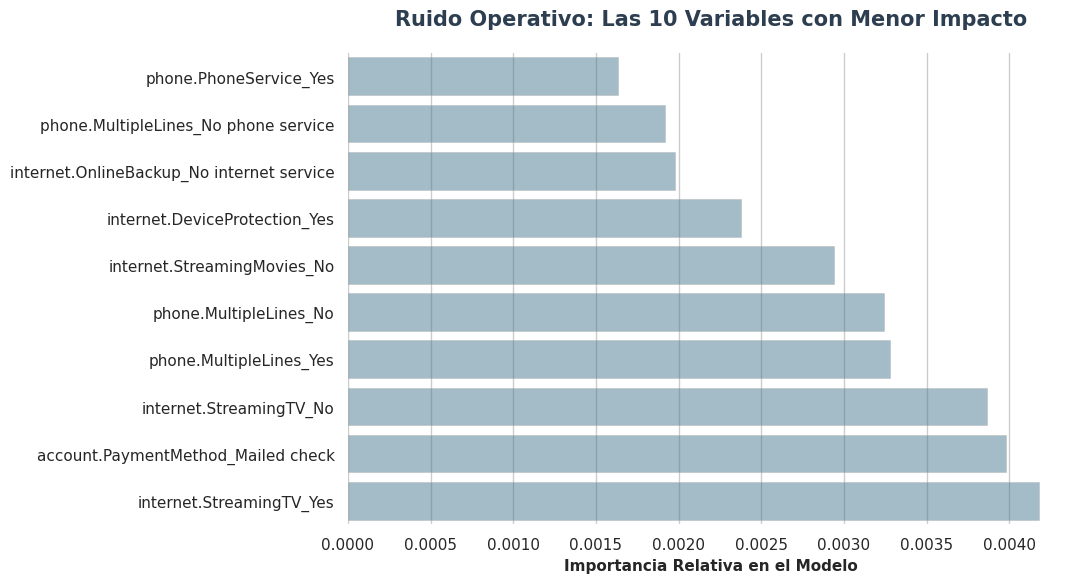

In [136]:
# Aislar el Bottom 10
bottom_10_features = df_importancias.tail(10).sort_values(by='Importancia', ascending=True)

# Visualización Consistente
plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    x='Importancia',
    y='Variable',
    data=bottom_10_features,
    color=color_lealtad,
    alpha=0.5,
    edgecolor="#aaaaaa", linewidth=0.5
)

plt.title("Ruido Operativo: Las 10 Variables con Menor Impacto",
          fontsize=15, fontweight='bold', color='#2c3e50', pad=20)
plt.xlabel("Importancia Relativa en el Modelo", fontsize=11, fontweight='bold')
plt.ylabel("")

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [137]:
import joblib

# Definimos el nombre del archivo final
nombre_archivo = 'modelo_rf_churn_campeon.pkl'

# Guardamos el pipeline completo (incluye preprocesamiento y el modelo Random Forest)
joblib.dump(rf_pipeline, nombre_archivo)

print(f"✅ Pipeline exportado exitosamente como: {nombre_archivo}")
print("El modelo está listo para ser desplegado en el entorno de producción.")

✅ Pipeline exportado exitosamente como: modelo_rf_churn_campeon.pkl
El modelo está listo para ser desplegado en el entorno de producción.


#Conclusión Ejecutiva: Estrategia de Retención Inteligente

##1. Resumen de la Solución

Se ha desarrollado e implementado con éxito un ecosistema predictivo basado en Machine Learning (Random Forest) para la detección proactiva de fuga de clientes (Churn). El modelo final ha demostrado una capacidad superior de generalización, logrando un Recall del 79%, lo que permite al negocio anticiparse a casi 8 de cada 10 cancelaciones potenciales antes de que estas se materialicen.

##2. Hallazgos Estratégicos (Drivers de Fuga)

El análisis de importancia de variables revela que el riesgo de abandono no es aleatorio, sino que está impulsado por tres pilares críticos:

###Tipo de Contrato:

Los clientes con contratos "Mes a Mes" presentan la mayor volatilidad. La transición de estos clientes hacia modelos de fidelización a largo plazo es la palanca de mayor impacto para reducir el Churn.

###Barrera de Salida por Antigüedad:

Existe una correlación directa entre la lealtad y la antigüedad del cliente. Los primeros 6 meses son críticos; una vez superado este umbral, la probabilidad de fuga disminuye drásticamente.

###Impacto de Cargos Totales:

El gasto acumulado actúa como un indicador de compromiso; sin embargo, los picos inesperados en cargos mensuales disparan las alertas de insatisfacción.

##3. Recomendaciones Operativas

###Acción Inmediata:

Desplegar el modelo exportado (modelo_rf_churn_campeon.pkl) en el flujo de datos mensual para generar listas de "Clientes en Alerta Roja".

###Intervención Focalizada:

Ejecutar campañas de retención específicas (ofertas de migración de contrato o bonos de lealtad) dirigidas exclusivamente al 79% de los clientes identificados por el modelo, optimizando así el retorno de inversión (ROI) del presupuesto de marketing.

###Monitoreo Continuo:

Se recomienda una re-evaluación del modelo cada trimestre para ajustar los patrones predictivos a los cambios en el comportamiento del mercado retail.